In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Carregar os dataframes
df_regclim = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_regularclimate_yearly.csv")
df_2y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_2y_yearly.csv")
df_4y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_4y_yearly.csv")
df_6y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_6y_yearly.csv")
df_8y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_8y_yearly.csv")



In [4]:
# Variables of interest
variables = ['npp', 'ctotal', 'evapm', 'ls']

# Mapping variable names to plot labels
variables_label = {
    'npp': 'NPP',
    'ctotal': 'Total Carbon',
    'evapm': 'Evapotranspiration',
    'ls': 'Num. PLSs'
}

# Compute relative differences (%) with respect to the regular climate scenario
for var in variables:
    df_2y[var + '_diff_relative'] = (
        (df_2y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100

    df_4y[var + '_diff_relative'] = (
        (df_4y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100

    df_6y[var + '_diff_relative'] = (
        (df_6y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100

    df_8y[var + '_diff_relative'] = (
        (df_8y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100


In [7]:
# Create simulation year (starting at 0)
df_regclim['sim_year'] = range(len(df_regclim))
df_2y['sim_year'] = range(len(df_2y))
df_4y['sim_year'] = range(len(df_4y))
df_6y['sim_year'] = range(len(df_6y))
df_8y['sim_year'] = range(len(df_8y))


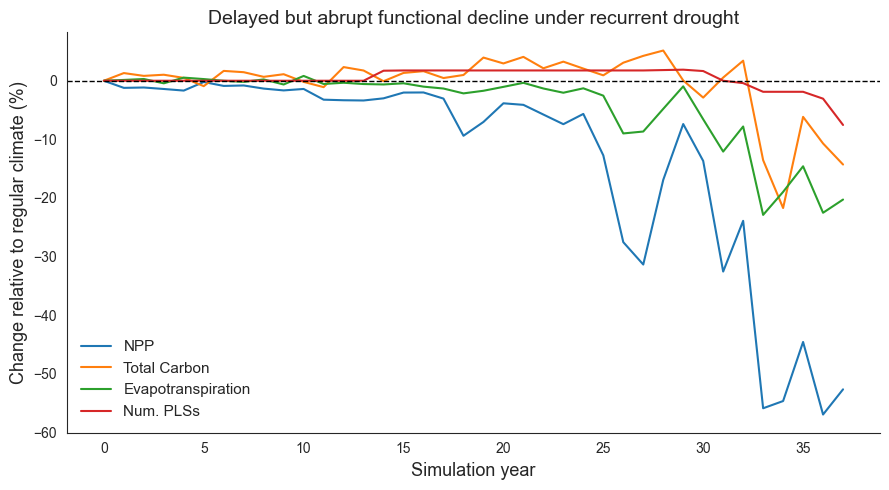

In [20]:

# Colorblind-safe palette (Okabe–Ito)
colors = {
    'npp':   '#0072B2',  # Blue
    'ctotal':'#D55E00',  # Vermillion (orange-red)
    'evapm': '#009E73',  # Bluish green
    'ls':    '#CC79A7'   # Reddish purple
}


plt.figure(figsize=(9, 5))

for var in variables:
    sns.lineplot(
        data=df_8y,
        x='sim_year',
        y=var + '_diff_relative',
        label=variables_label[var]

    )
# Reference line
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# Labels
plt.xlabel('Simulation year', fontsize=13)
plt.ylabel('Change relative to regular climate (%)', fontsize=13)

# Title (interpretative)
plt.title(
    'Delayed but abrupt functional decline under recurrent drought',
    fontsize=14
)

# Axis ticks
plt.xticks(range(0, df_8y['sim_year'].max() + 1, 5))

# Clean look
sns.despine()
plt.grid(False)
sns.lineplot(
    data=df_8y,
    x='sim_year',
    y=var + '_diff_relative',
    label=variables_label[var],
    color=colors[var],      # ← THIS LINE
    linewidth=2.2
)


plt.legend(
    frameon=False,
    fontsize=11,
    loc='lower left'
)
plt.tight_layout()
plt.show()
